In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [11]:
df = pd.read_csv('notebook/data/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

## Health-Checkup of Dataset

In [12]:
print("Five Rows from the top:\n", df.head())

Five Rows from the top:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [13]:
print("Five Rows from Tail:\n", df.tail())

Five Rows from Tail:
      PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [14]:
print("Statrics of Dataset:\n", df.describe())

Statrics of Dataset:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [15]:
df.shape

(891, 12)

In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [17]:
missing_cols = pd.DataFrame({
    'columns': df.columns,
    'Rows': len(df),
    'Dtype': df.dtypes.values,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().sum().values / len(df))*100
}).sort_values('Missing Percentage', ascending=False).round(2)

In [18]:
print("Missing Summary of Titanic Dataset:\n", missing_cols)

Missing Summary of Titanic Dataset:
         columns  Rows    Dtype  Missing Count  Missing Percentage
10        Cabin   891      str            687               77.10
5           Age   891  float64            177               19.87
11     Embarked   891      str              2                0.22
0   PassengerId   891    int64              0                0.00
3          Name   891      str              0                0.00
2        Pclass   891    int64              0                0.00
1      Survived   891    int64              0                0.00
4           Sex   891      str              0                0.00
7         Parch   891    int64              0                0.00
6         SibSp   891    int64              0                0.00
9          Fare   891  float64              0                0.00
8        Ticket   891      str              0                0.00


## Univariate Analysis

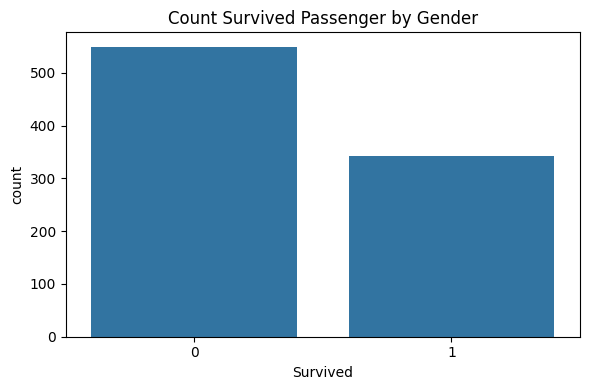

In [19]:
## Count plot
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)
plt.title("Count Survived Passenger by Gender")
plt.tight_layout()
plt.show()

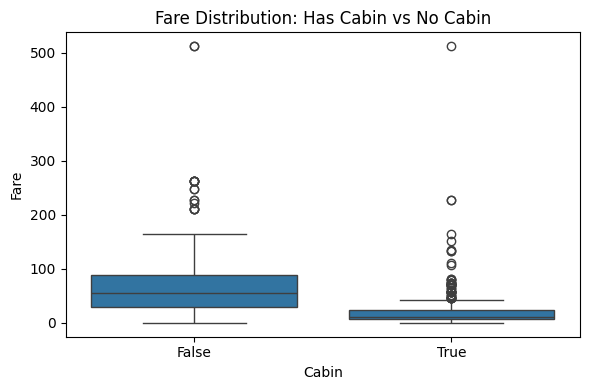

In [20]:
## Relationship B/W Fare and Cabin
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cabin'].isna(), y=df['Fare'])
plt.title("Fare Distribution: Has Cabin vs No Cabin")
plt.tight_layout()
plt.show()

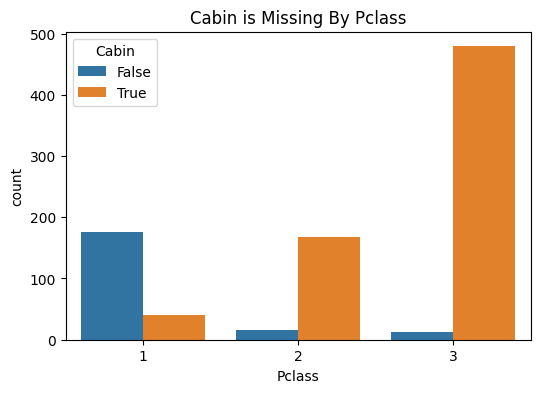

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Pclass', hue=df['Cabin'].isna())
plt.title("Cabin is Missing By Pclass")
plt.show()

## Bivariate Analysis

In [22]:
print(df.select_dtypes(include=['object']))

                                                  Name     Sex  \
0                              Braund, Mr. Owen Harris    male   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female   
2                               Heikkinen, Miss. Laina  female   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   
4                             Allen, Mr. William Henry    male   
..                                                 ...     ...   
886                              Montvila, Rev. Juozas    male   
887                       Graham, Miss. Margaret Edith  female   
888           Johnston, Miss. Catherine Helen "Carrie"  female   
889                              Behr, Mr. Karl Howell    male   
890                                Dooley, Mr. Patrick    male   

               Ticket Cabin Embarked  
0           A/5 21171   NaN        S  
1            PC 17599   C85        C  
2    STON/O2. 3101282   NaN        S  
3              113803  C123        S  
4           

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1800\344189068.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']))


Sex
female    False
male      False
Name: Survived, dtype: bool


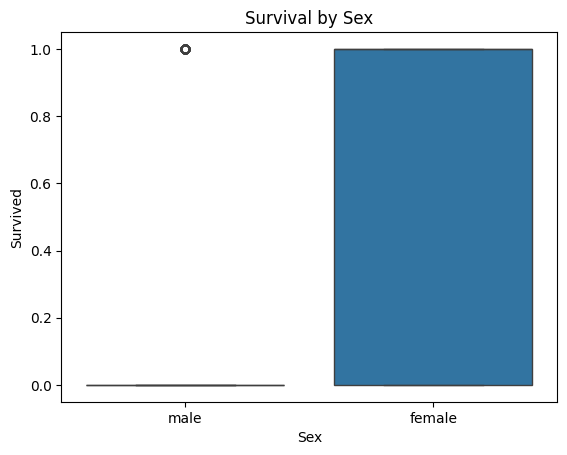

Cabin
A10    False
A14    False
A16    False
A19    False
A20    False
       ...  
F33    False
F38    False
F4     False
G6     False
T      False
Name: Survived, Length: 147, dtype: bool


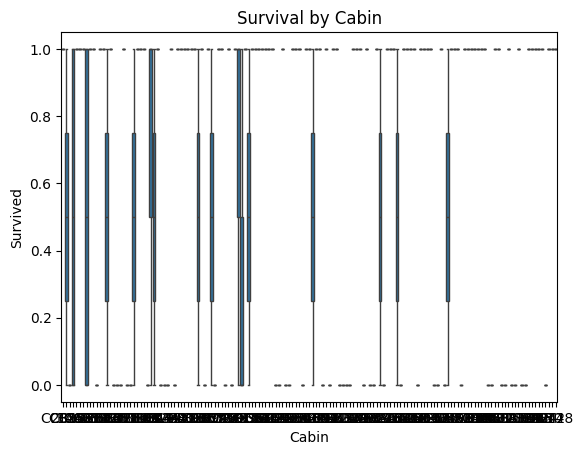

Embarked
C    False
Q    False
S    False
Name: Survived, dtype: bool


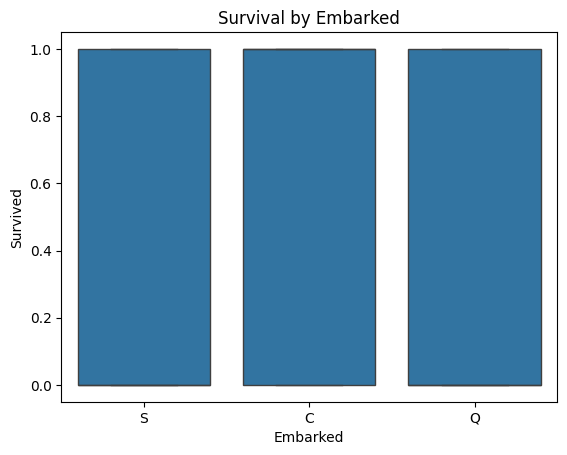

In [23]:
## Caategorical vs Target
categorical_cols = ['Sex', 'Cabin', 'Embarked']

for col in categorical_cols:
    survial_rate = df.groupby(col)['Survived'].mean().isna()
    print(survial_rate)

    sns.boxplot(x=col, y='Survived', data=df)
    plt.title(f"Survival by {col}")
    plt.show()

In [24]:
numerical_cols = df.select_dtypes(include=['int64','float64'])

In [25]:
numerical_cols.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64

In [26]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']


Age by Survival

Fare by Survival

SibSp by Survival

Parch by Survival

Pclass by Survival


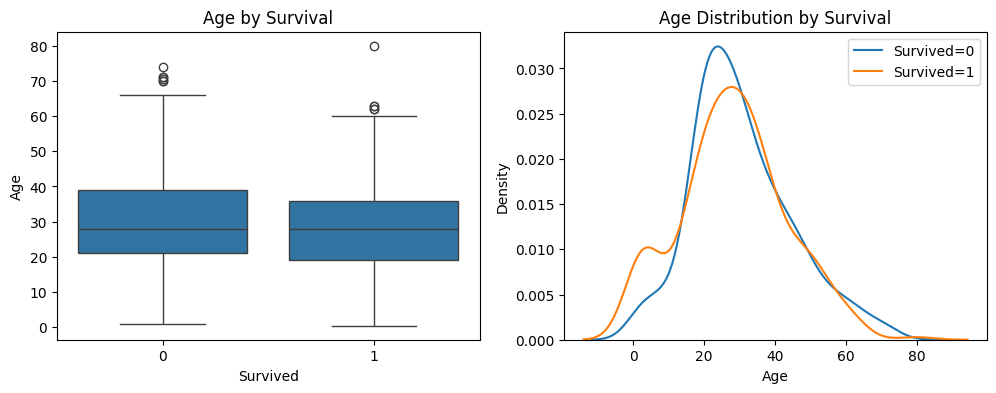

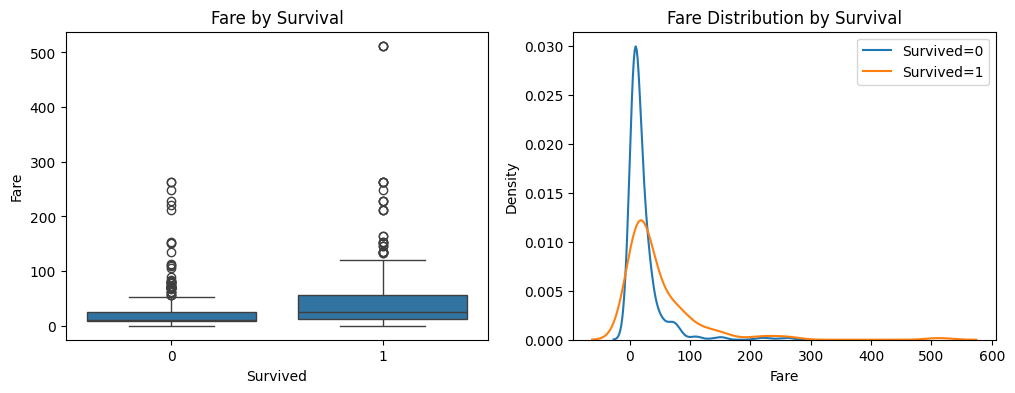

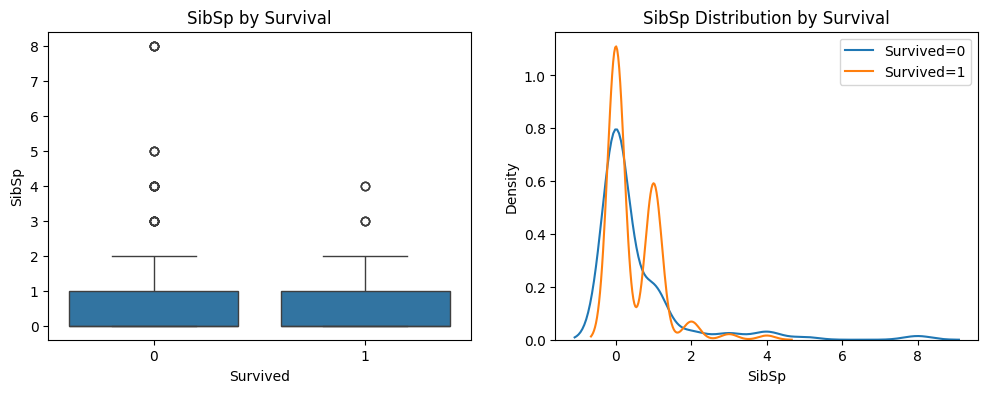

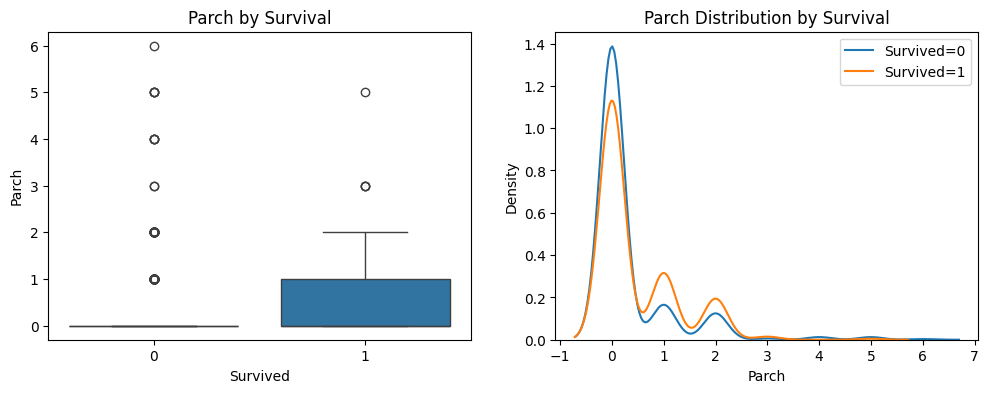

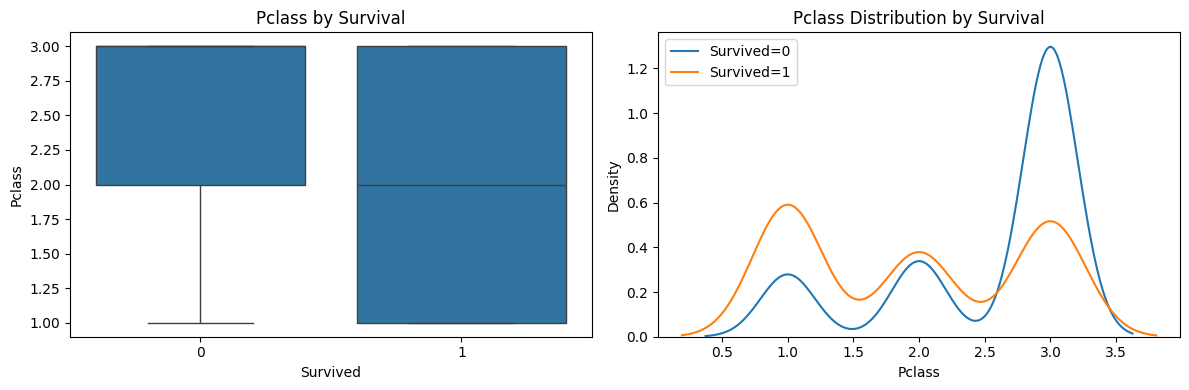

In [27]:
## Numerical vs Target
for feature in num_cols:
    print(f"\n{feature} by Survival")
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    sns.boxplot(x='Survived', y=feature, data=df, ax=axes[0])
    plt.title(f"{feature} By Survived")
    axes[0].set_title(f"{feature} by Survival")

    ## Distribution of Survival
    for survival in [0, 1]:
        sns.kdeplot(df[df['Survived']== survival][feature], label=f'Survived={survival}', ax=axes[1])
        axes[1].set_title(f'{feature} Distribution by Survival')
        axes[1].legend()
plt.tight_layout()
plt.show()

In [28]:
## Correlation Matrix
print("Correlation Matrix:\n")
numerical_df= df[num_cols + ['Survived']].copy()
corr_matrix = numerical_df.corr()
print(corr_matrix['Survived'].sort_values(ascending = False))

Correlation Matrix:

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


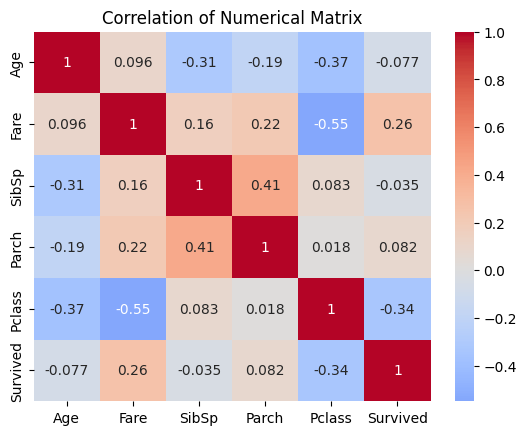

In [29]:
## Heatmap
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm', center=0)
plt.title("Correlation of Numerical Matrix")
plt.show()

## Multivariate Analysis

In [30]:
## Pclass, Sex and Survival
print("\n Pclass and Sex interaction:")
pclas_sex_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
print(pclas_sex_survival)


 Pclass and Sex interaction:
Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


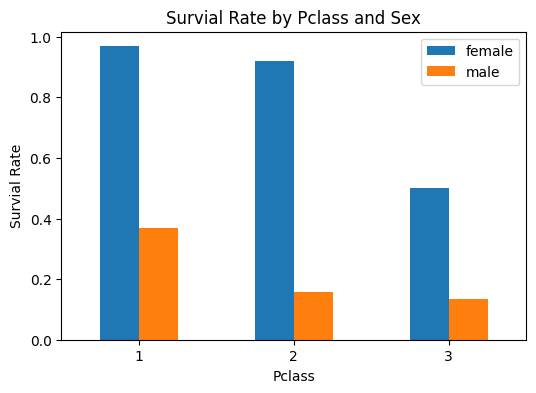

In [31]:
pclas_sex_survival.plot(kind= 'bar', figsize=(6,4))
plt.title("Survial Rate by Pclass and Sex")
plt.ylabel("Survial Rate")
plt.xticks(rotation =0)
plt.legend()
plt.show()

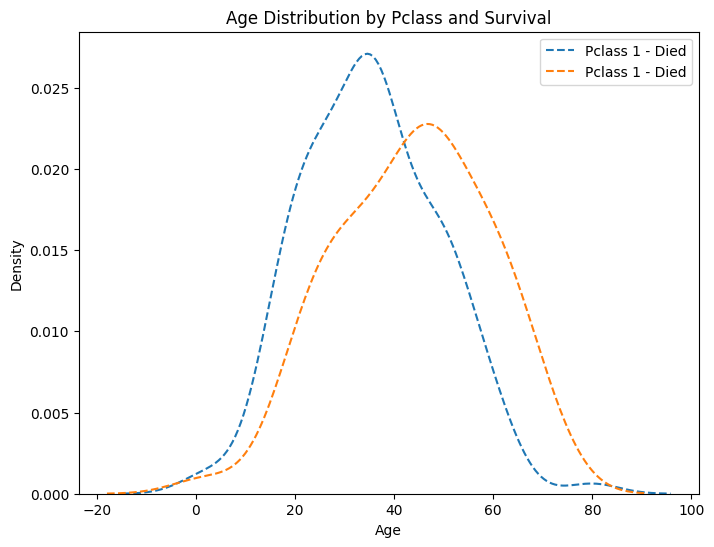

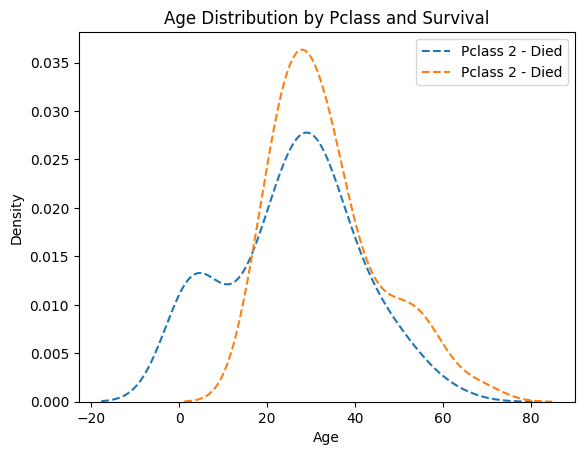

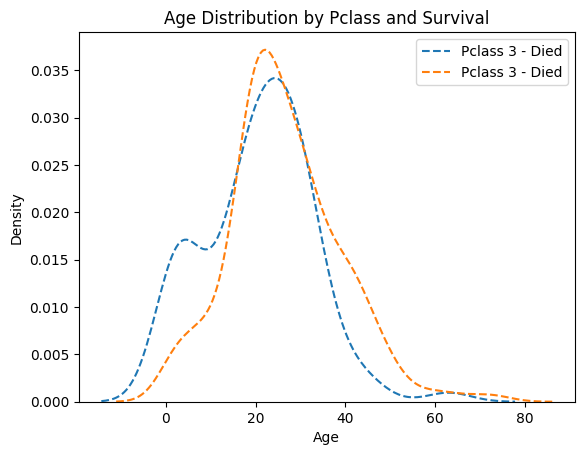

In [32]:
plt.figure(figsize=(8, 6))
for pclass in [1, 2, 3]:
    subset = df[df['Pclass'] == pclass]
    sns.kdeplot(subset[subset['Survived'] == 1]['Age'].dropna(), label=f'Pclass {pclass} - Died', linestyle='--')
    sns.kdeplot(subset[subset['Survived'] == 0]['Age'].dropna(), label=f'Pclass {pclass} - Died', linestyle='--')
    plt.title("Age Distribution by Pclass and Survival")
    plt.xlabel('Age')
    plt.legend()
    plt.show()

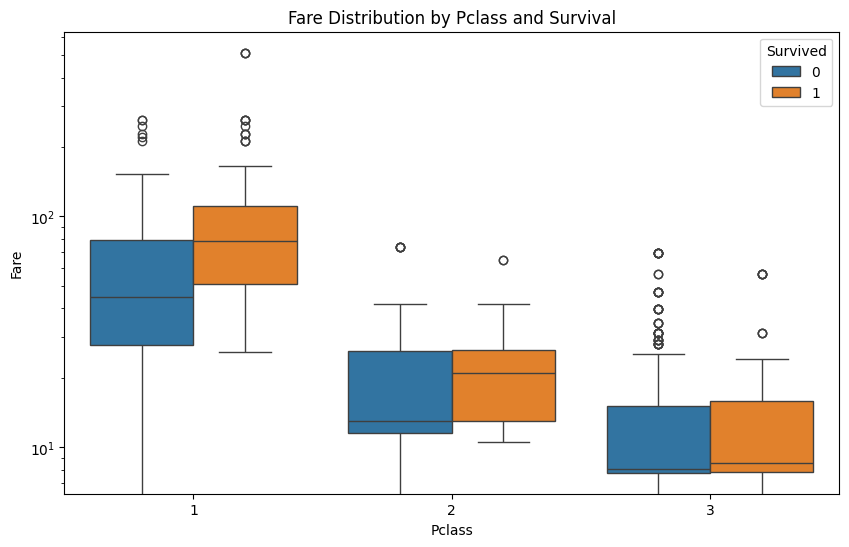

In [33]:
## Fare, Pclass and Survival

plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)
plt.title("Fare Distribution by Pclass and Survival")
plt.yscale('log')
plt.show()